X_train 크기 : (4157, 3)
X_valid 크기 : (1040, 3)
X_test 크기  : (1300, 3)

===== 검증세트 평가 =====
정확도: 0.8298076923076924
정밀도: 0.9329529243937232
재현율: 0.8341836734693877
F1-score: 0.8808080808080808

분류 리포트:
              precision    recall  f1-score   support

         0.0       0.62      0.82      0.70       256
         1.0       0.93      0.83      0.88       784

    accuracy                           0.83      1040
   macro avg       0.77      0.83      0.79      1040
weighted avg       0.86      0.83      0.84      1040


===== 테스트세트 평가 =====
정확도: 0.8315384615384616
정밀도: 0.9280089988751407
재현율: 0.8418367346938775
F1-score: 0.8828250401284109

분류 리포트:
              precision    recall  f1-score   support

         0.0       0.62      0.80      0.70       320
         1.0       0.93      0.84      0.88       980

    accuracy                           0.83      1300
   macro avg       0.78      0.82      0.79      1300
weighted avg       0.85      0.83      0.84      1300



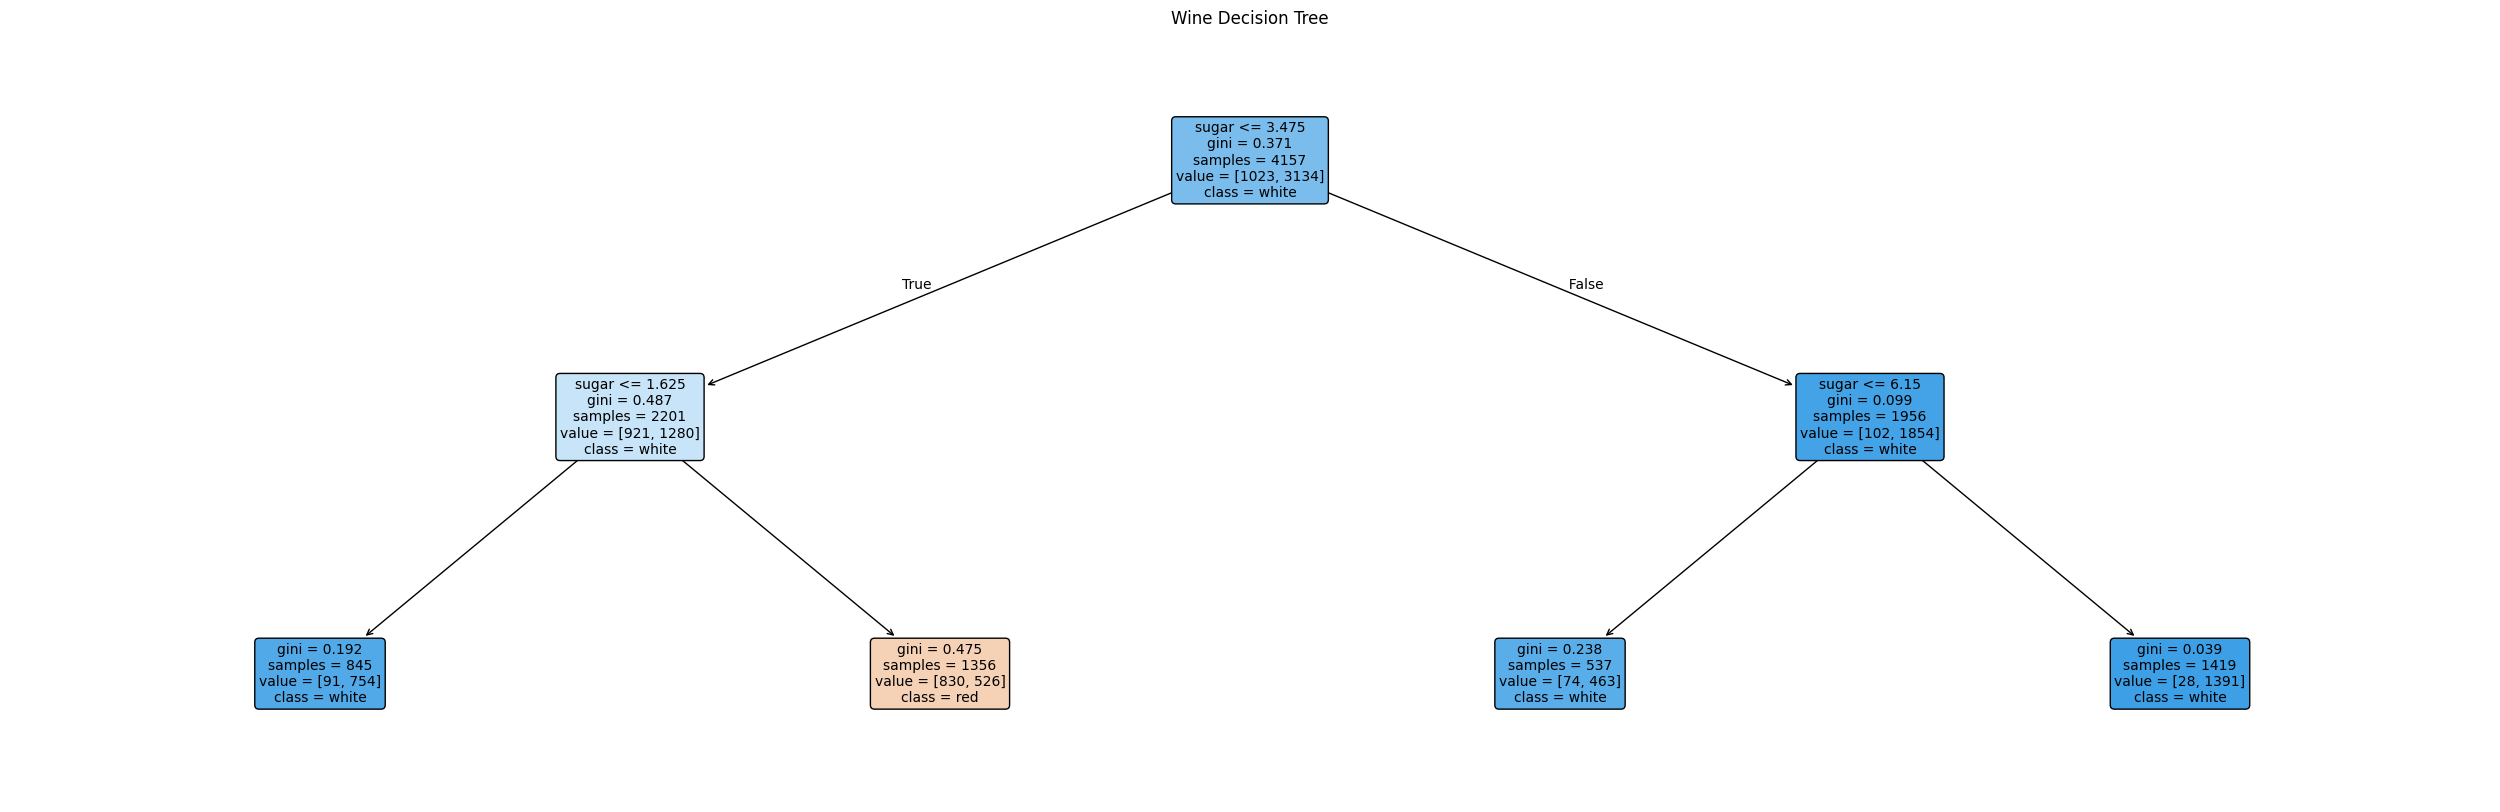

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import cross_validate

# 1. 데이터 불러오기
wine = pd.read_csv("wine.csv")

# 2. 입력(X) / 정답(y)
X = wine[['alcohol', 'sugar', 'pH']]
y = wine['class']

# 3. 먼저 train+valid / test 분리
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. 다시 train / valid 분리
# 전체 기준으로 보면:
# train = 64%, valid = 16%, test = 20%
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size=0.2,   # train_valid의 20%를 valid로
    random_state=42,
    stratify=y_train_valid
)

print("X_train 크기 :", X_train.shape)
print("X_valid 크기 :", X_valid.shape)
print("X_test 크기  :", X_test.shape)
print()

# 5. 결정트리 모델 생성
findout = DecisionTreeClassifier(max_depth=2, random_state=42)

# 6. 학습
findout.fit(X_train, y_train)

# 7. 검증세트 예측
y_valid_pred = findout.predict(X_valid)

print("===== 검증세트 평가 =====")
print("정확도:", accuracy_score(y_valid, y_valid_pred))
print("정밀도:", precision_score(y_valid, y_valid_pred))
print("재현율:", recall_score(y_valid, y_valid_pred))
print("F1-score:", f1_score(y_valid, y_valid_pred))
print()
print("분류 리포트:")
print(classification_report(y_valid, y_valid_pred))

# 8. 테스트세트 예측
y_test_pred = findout.predict(X_test)

print("\n===== 테스트세트 평가 =====")
print("정확도:", accuracy_score(y_test, y_test_pred))
print("정밀도:", precision_score(y_test, y_test_pred))
print("재현율:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))
print()
print("분류 리포트:")
print(classification_report(y_test, y_test_pred))

# 9. 트리 시각화
plt.figure(figsize=(32, 10))
plot_tree(
    findout,
    feature_names=['alcohol', 'sugar', 'pH'],
    class_names=['red', 'white'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Wine Decision Tree")
plt.show()

In [16]:
print(findout.feature_importances_)

[0. 1. 0.]


정확도 (Accuracy):  84.08%
정밀도 (Precision):  88.15%
재현율 (Recall):  91.12%
F1 점수:  89.61%


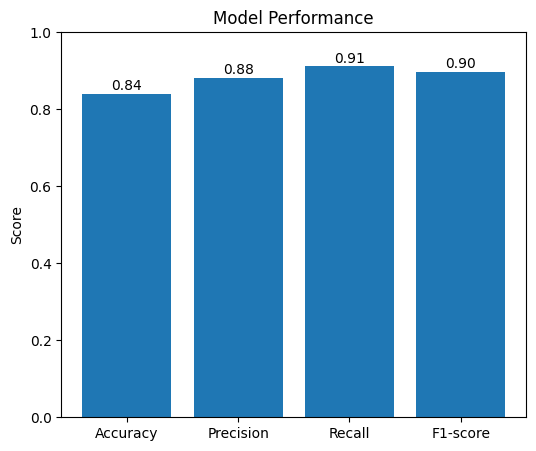

In [8]:
train_proba = findout.predict_proba(X_train)
test_proba = findout.predict_proba(X_test)

train_mean = train_proba.mean()
test_mean = test_proba.mean()
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"정확도 (Accuracy): {accuracy : .2%}")
print(f"정밀도 (Precision): {precision : .2%}")
print(f"재현율 (Recall): {recall : .2%}")
print(f"F1 점수: {f1 : .2%}")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 성능 지표 계산
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

scores = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# 그래프
plt.figure(figsize=(6,5))
plt.bar(labels, scores)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Performance")

for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

X_train 크기 : (5197, 3)
X_test 크기  : (1300, 3)

===== 교차검증 결과 =====
train accuracy: [0.99807554 0.99807554 0.9983165  0.998076   0.9983165 ]
test accuracy : [0.86730769 0.86923077 0.84696824 0.85370549 0.84985563]
평균 test accuracy : 0.8574135633375286

train precision: [0.99936102 0.99936102 0.99936123 0.99968041 0.99936143]
test precision : [0.9151671  0.90909091 0.91064389 0.90293742 0.90243902]
평균 test precision : 0.9080556676789113

train recall: [0.99808551 0.99808551 0.99840459 0.99776715 0.9984051 ]
test recall : [0.90816327 0.91836735 0.88392857 0.90293742 0.89782886]
평균 test recall : 0.9022450934396747

train f1: [0.99872286 0.99872286 0.99888268 0.99872286 0.99888304]
test f1 : [0.91165173 0.91370558 0.89708738 0.90293742 0.90012804]
평균 test f1 : 0.9051020304204339

===== 최종 테스트세트 평가 =====
정확도: 0.8653846153846154
정밀도: 0.905337361530715
재현율: 0.9173469387755102
F1-score: 0.9113025848960973

분류 리포트:
              precision    recall  f1-score   support

         0.0       0.74   

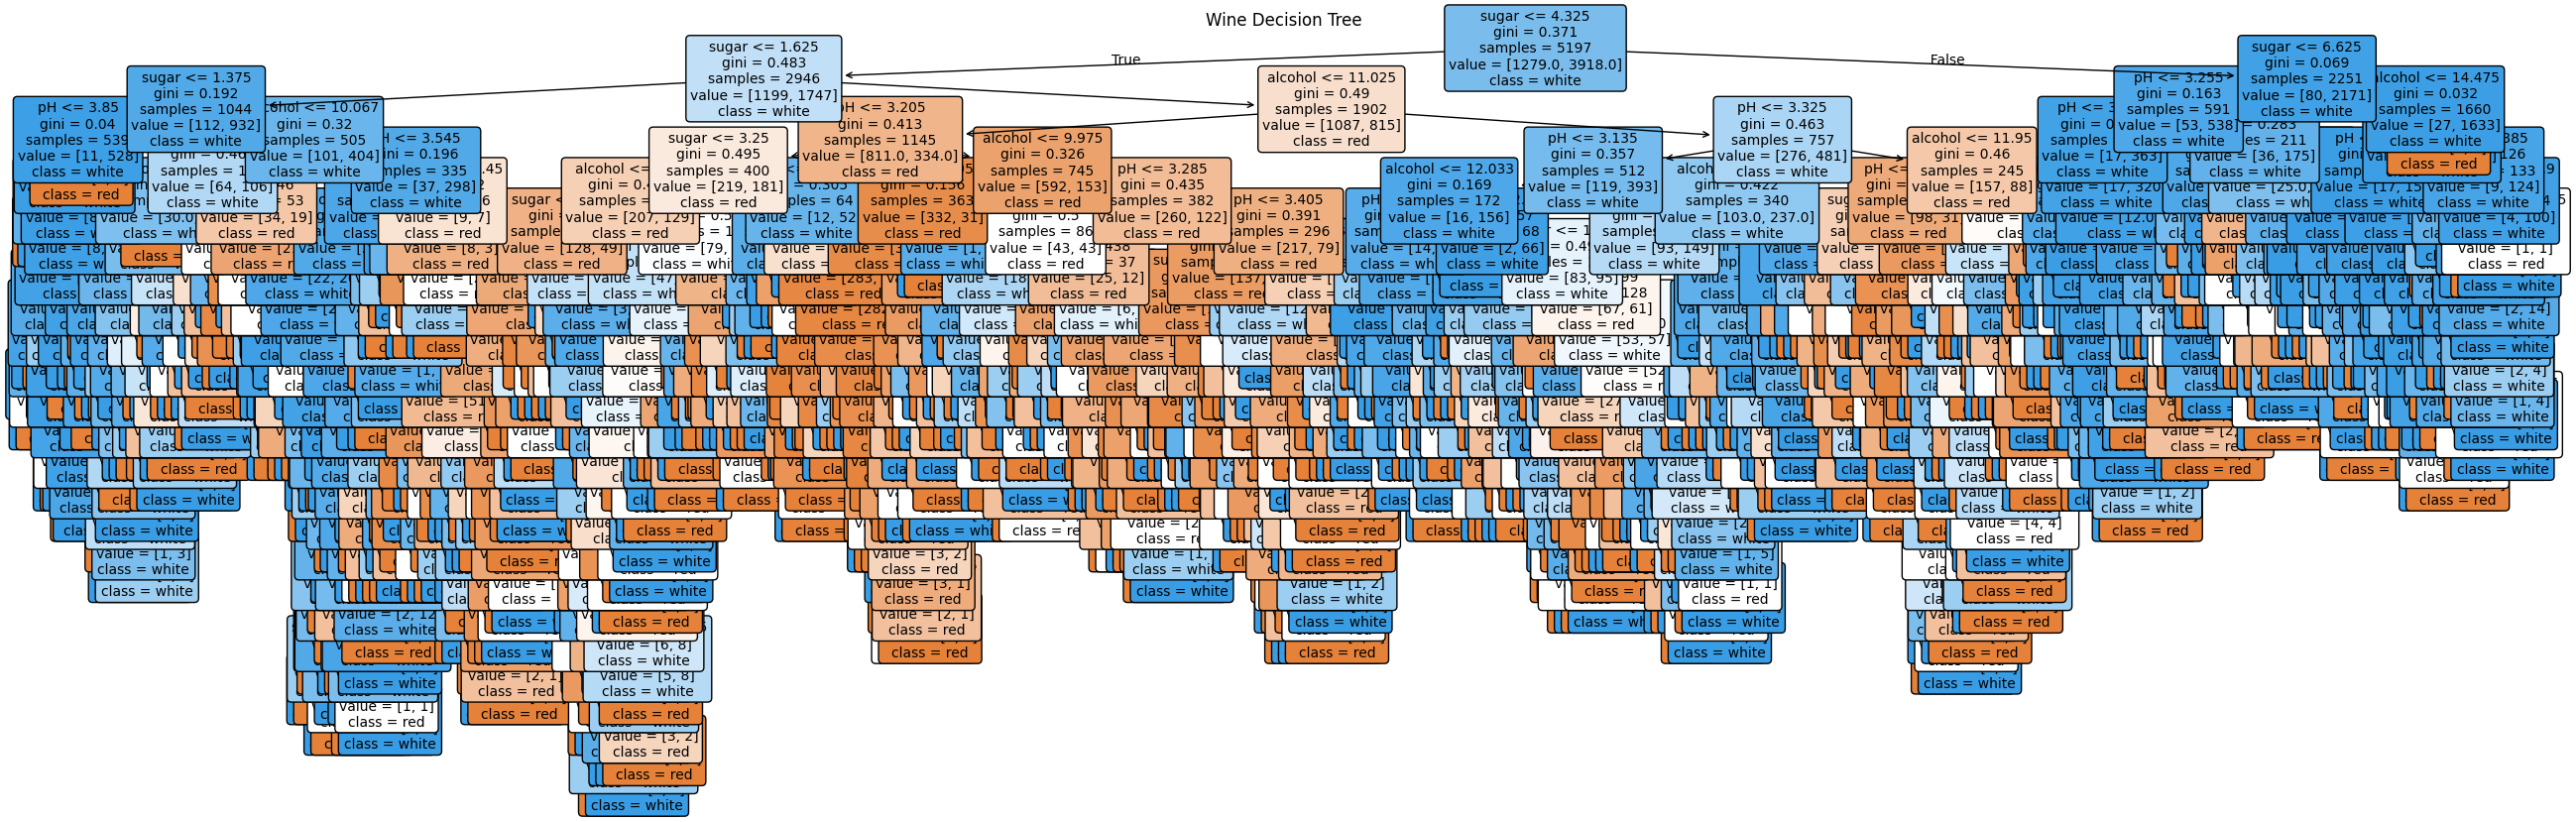

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score
)

# 1. 데이터 불러오기
wine = pd.read_csv("wine.csv")

# 2. 입력(X) / 정답(y)
X = wine[['alcohol', 'sugar', 'pH']]
y = wine['class']

# 3. train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train 크기 :", X_train.shape)
print("X_test 크기  :", X_test.shape)
print()

# 4. 모델 생성
findout = DecisionTreeClassifier(random_state=42)

# 5. 교차검증 설정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6. cross_validate로 교차검증
cv_results = cross_validate(
    estimator=findout,
    X=X_train,
    y=y_train,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=True
)

# 7. 교차검증 결과 출력
print("===== 교차검증 결과 =====")
print("train accuracy:", cv_results['train_accuracy'])
print("test accuracy :", cv_results['test_accuracy'])
print("평균 test accuracy :", cv_results['test_accuracy'].mean())
print()

print("train precision:", cv_results['train_precision'])
print("test precision :", cv_results['test_precision'])
print("평균 test precision :", cv_results['test_precision'].mean())
print()

print("train recall:", cv_results['train_recall'])
print("test recall :", cv_results['test_recall'])
print("평균 test recall :", cv_results['test_recall'].mean())
print()

print("train f1:", cv_results['train_f1'])
print("test f1 :", cv_results['test_f1'])
print("평균 test f1 :", cv_results['test_f1'].mean())
print()

# 8. 전체 훈련데이터로 다시 학습
findout.fit(X_train, y_train)

# 9. 테스트세트 예측
y_test_pred = findout.predict(X_test)

print("===== 최종 테스트세트 평가 =====")
print("정확도:", accuracy_score(y_test, y_test_pred))
print("정밀도:", precision_score(y_test, y_test_pred))
print("재현율:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))
print()
print("분류 리포트:")
print(classification_report(y_test, y_test_pred))

# 10. 트리 시각화
plt.figure(figsize=(32, 10))
plot_tree(
    findout,
    feature_names=['alcohol', 'sugar', 'pH'],
    class_names=['red', 'white'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Wine Decision Tree")
plt.show()

In [36]:
import numpy as np
print(cv_results)
print()
print(np.mean(cv_results['test_accuracy']))

{'fit_time': array([0.00606346, 0.00604653, 0.00622582, 0.00603437, 0.00602221]), 'score_time': array([0.00776863, 0.00747633, 0.00707793, 0.00803947, 0.00701547]), 'test_accuracy': array([0.86730769, 0.86923077, 0.84696824, 0.85370549, 0.84985563]), 'train_accuracy': array([0.99807554, 0.99807554, 0.9983165 , 0.998076  , 0.9983165 ]), 'test_precision': array([0.9151671 , 0.90909091, 0.91064389, 0.90293742, 0.90243902]), 'train_precision': array([0.99936102, 0.99936102, 0.99936123, 0.99968041, 0.99936143]), 'test_recall': array([0.90816327, 0.91836735, 0.88392857, 0.90293742, 0.89782886]), 'train_recall': array([0.99808551, 0.99808551, 0.99840459, 0.99776715, 0.9984051 ]), 'test_f1': array([0.91165173, 0.91370558, 0.89708738, 0.90293742, 0.90012804]), 'train_f1': array([0.99872286, 0.99872286, 0.99888268, 0.99872286, 0.99888304])}

0.8574135633375286


In [37]:
from sklearn.model_selection import GridSearchCV
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
          'max_depth' : range(5,20,1),
          'min_samples_split' : range(2,100,10)
         }
gs = GridSearchCV(findout, params, n_jobs=-1)
gs.fit(X_train, y_train)


GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(5, 20),
                         'min_impurity_decrease': array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008,
       0.0009]),
                         'min_samples_split': range(2, 100, 10)})

In [38]:
dt = gs.best_estimator_
print(dt.score(X_test, y_test))

0.8692307692307693


In [39]:
print(gs.best_params_)

{'max_depth': 19, 'min_impurity_decrease': np.float64(0.0002), 'min_samples_split': 2}


In [41]:
print(np.max(gs.cv_results_['mean_test_score']))

0.8731935292811135


In [42]:
from scipy.stats import uniform, randint
rgen = randint(0,10)
rgen.rvs(10)

array([2, 1, 1, 5, 5, 6, 7, 1, 5, 3])

In [43]:
np.unique(rgen.rvs(1000), return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([107, 116,  85, 100,  96, 106,  91, 104, 103,  92]))

In [ ]:
ugen = uniform(0,1)
ugen.rvs(10)
params = {'min_impurity_decrease' : uniform(0.0001, 0.001),
         'max_depth' : randint(20,50),
         'min_samples_split' : randint(2,25),
         'min_samples_leaf' : }